# 2. Clustering (Descriptive Analysis)

You must construct clustering pipelines using:
*  k-means
*  DBSCAN

## Requirements:
* When clustering, drop the column track_genre.
* For k-means,
* determine a suitable value of k,
* compute the clustering for at least two different values of k and compare
them.
* Visualise clusters.
* Discuss:
  * Whether the clusters reveal meaningful structure.
  * Whether they align with known genre information.
* Explain why clustering succeeded or failed.
* Select and justify the final clustering solution

## A. Importing data and Preprocessing

In [72]:
#imports style setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [86]:
df = pd.read_csv("./tracks2026.csv")#reads csv set
df.head(5)
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


In [74]:
df_with_drop = df.drop(["track_id","track_genre","explicit","mode","key","time_signature"], axis=1)#creating a set without the following genres
df_with_drop = df_with_drop.dropna()#dropping all null columns

df_with_drop = df_with_drop[df_with_drop["loudness"] <= 0]#dropping outliers from loudness
print("Remaining columns" ,df_with_drop.columns.tolist())

df_with_drop.head(5)

Remaining columns ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,44.0,203337,0.608,0.553,-3.493,0.0271,0.3930,0.000000,0.1530,0.541,143.993
1,83.0,208786,0.775,0.613,-4.586,0.0542,0.1090,0.000023,0.1340,0.797,100.066
2,49.0,262373,0.797,0.612,-9.043,0.0313,0.2710,0.000011,0.3140,0.919,118.162
3,0.0,191733,0.582,0.829,-3.517,0.1930,0.0522,0.000000,0.2640,0.716,90.959
4,41.0,283706,0.705,0.713,-6.676,0.0437,0.2600,0.000016,0.0499,0.498,129.899


To properly prepare the data for clustering we do the following:
- We drop all columns that contain non-numerical data as they can't be used to calculate the distance between them. Columns such as Key and time_signature are dropped as well as they are categorical integers.
- We then drop al rows missing data which we found to be 40 rows in total in the EDA section of this project.
- Finally, it was found in the EDA section that loudness has a massive outlier of 800000 so to handle that outlier as well as any others we drop any value above 0 as loudness should be in the negatives anyway.

## B. Scaling the Data

In [75]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_array = scaler.fit_transform(df_with_drop)#calculates the mean and SD for every column and applies the formula ((x-mean)/SD) to scale them

df_scaled = pd.DataFrame(scaled_array, columns=df_with_drop.columns)#puts column names back

df_scaled.describe().round(2)#rounds and provides statistical summary

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1960.00,1960.00,1960.00,1960.00,1960.00,1960.00,1960.00,1960.00,1960.00,1960.00,1960.00
mean,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.36,-2.77,-3.26,-2.86,-4.77,-0.74,-1.06,-0.25,-1.14,-2.13,-2.42
25%,-1.30,-0.64,-0.64,-0.66,-0.56,-0.58,-0.88,-0.25,-0.58,-0.79,-0.81
50%,0.18,-0.11,0.07,0.06,0.16,-0.41,-0.37,-0.25,-0.40,-0.02,-0.05
75%,0.86,0.50,0.74,0.78,0.69,0.07,0.69,-0.25,0.27,0.80,0.69
max,2.06,6.04,2.29,1.92,2.54,5.74,2.47,7.74,5.34,1.91,3.01


We first have to scale the data before clustering to keep every feature equally weighted which is important when calculating the euclidian distance.

To scale we use scikit-learns standard scaler to scale the values of all the columns. The standard scaler scales each value by using the formula ((x-mean)/SD). This causes the mean of all values to become 0 and the standard deviation to become 1.

## C. Calculating Optimal Amount of Clusters Using Elbow Method

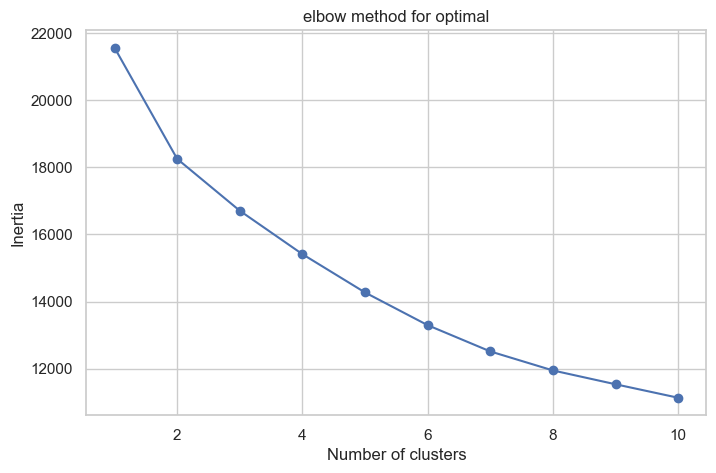

In [76]:
inertia = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)#the model is looking for k groups with 10 different starting positions
    kmeans.fit(df_scaled)#based on scaled features trys to fit songs into groups
    inertia.append(kmeans.inertia_)#saves to intertia list

plt.figure(figsize = (8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("elbow method for optimal")
plt.show()


Before clustering we first utilize the elbow method to help determine the optimal amount of clusters needed for this dataset.

The elbow method works by calculating the sum of squared error for each given value of k(in our case 1-10). As we increase cluster size SSE tends to decrease towards 0. after plotting this it will typically look like an arm and the elbow of the arm represents when we get diminishing returns from k have found the optimal cluster amount.

For out graph the elbow of the graph is clearly between the values of 4 and 6 so we decided to use the value of 5 to best represent this.

## D. Clustering the Data

In [77]:
df_clean_with_genres = df.dropna().copy()
df_clean_with_genres = df_clean_with_genres[df_clean_with_genres["loudness"] <= 0]#just a copy of the list with the dropped columns

kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)#uses optimal cluster of 5
cluster_labels = kmeans_final.fit_predict(df_scaled)#predicts where each of the songs fit based on scaled values

df_with_results = df_with_drop.copy()
df_clean_with_genres['cluster_id'] = cluster_labels

comparison = pd.crosstab(df_clean_with_genres['cluster_id'], df_clean_with_genres['track_genre'])
print(comparison)

track_genre  hip-hop  indie-pop  pop  r-n-b  synth-pop
cluster_id                                            
0                  1         15    4      1         27
1                 23        200  149     79         56
2                 87         35   54     39          6
3                 44         92   90     72        124
4                137        152  191    102        180


Here we cluster the data with the amount of clusters equals to five. Here is what this clustering can reveal to us:
1. Cluster 0 is the smallest and seems to consist of outliers in the data which the clustering caught successfully using this cluster.
2. Cluster 1 groups the majority of pop and indie pop together. This makes sense as these genres have a lot in similarity's in common as indie pop is sub-genre of pop.
3. Cluster 2 has the highest concentration of hip-hop music which is probably due to the speechiness feature which was stated to be the most discriminative feature in the EDA.
4. Cluster 3 primarily consists of synth-pop and other types pop which might suggest that it grouped these based on common factors such as danceability over factors like speechiness which would explain why hip-hop is so low for this cluster.
5. Cluster 4 is the largest cluster and serves as a catch-all cluster with high numbers for all genres. This suggests that cluster 4 might be based on factors such as energy and possibly duration as both of these features are heavily based on trends in the music industry and will not be specific to certain genres,

In [84]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_4 = kmeans_4.fit_predict(df_scaled)

df_clean_with_genres["cluster_id_4"] = cluster_labels_4
comparison_4 = pd.crosstab(df_clean_with_genres['cluster_id_4'], df_clean_with_genres['track_genre'])
print(comparison_4)

track_genre   hip-hop  indie-pop  pop  r-n-b  synth-pop
cluster_id_4                                           
0                  26        201  157     81         67
1                   1         16    5      1         29
2                 180        129  179     83         78
3                  85        148  147    128        219


To compare to different size clusters we have also clustered using a cluster size of 4 to see how they compare.

The main detail we noticed through changing the cluster size from five to four was the fact that the algorithm failed to separate hip-hop into its own distinct group unlike what was seen with cluster two of the previous attempt. Another detail we noticed is that even though we reduced the cluster amount the outlier group was distinct enough that the algorithm identified these as their own unique cluster.

We decided to stick with a cluster size of five as this did a better job of defining the hip-hop genre compared to the cluster size of 4.

## E. Visualising the Data

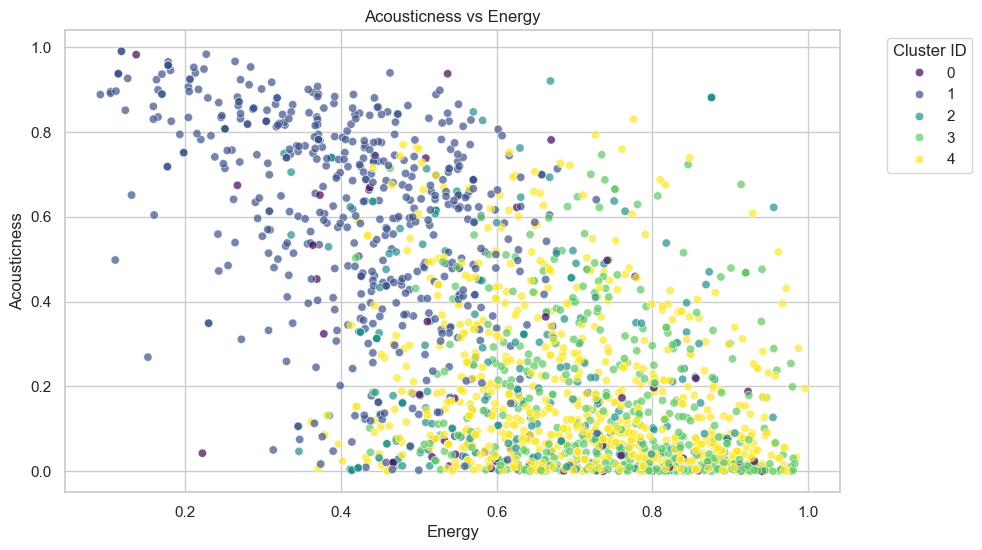

In [79]:
plt.figure(figsize = (10, 6))

sns.scatterplot(
    data=df_clean_with_genres,
    x="energy",
    y="acousticness",
    hue="cluster_id",
    palette="viridis",
    alpha=0.7,
)

plt.title("Acousticness vs Energy")
plt.xlabel("Energy")
plt.ylabel("Acousticness")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


Here we visualize the clusters on a scattergraph. we are plotting them against the features acoustiness and Energy. The majority of the clusters are on the bottom right which makes sense considering the average song has a high energy based on trends. Most of the points that have a high acoustiness but high energy belong to cluster one this makes sense as the majority of cluster 1 belong to indie pop which as a genre tends to utilize a more acoustic and mellow sound.

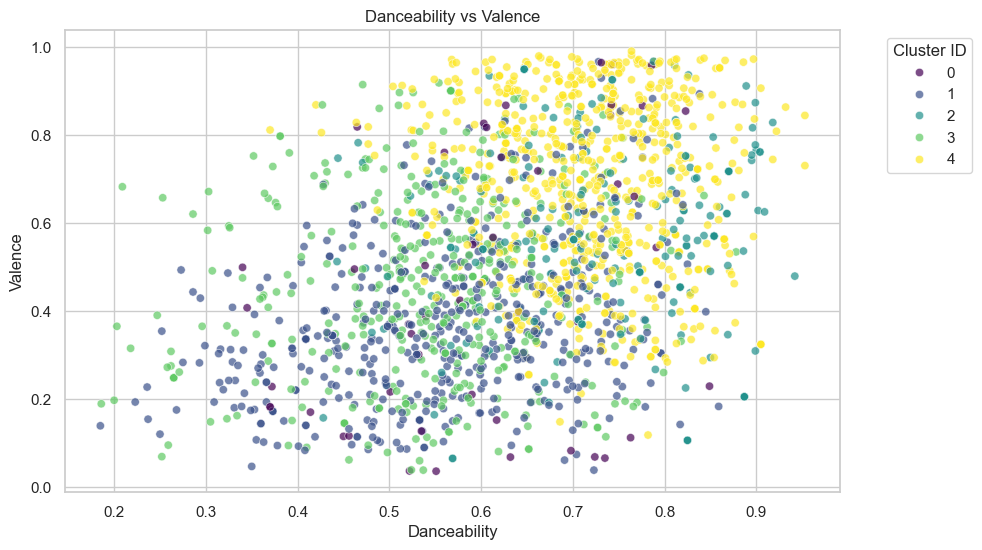

In [80]:
plt.figure(figsize = (10, 6))

sns.scatterplot(
    data=df_clean_with_genres,
    x="danceability",
    y="valence",
    hue="cluster_id",
    palette="viridis",
    alpha=0.7,
)

plt.title("Danceability vs Valence")
plt.xlabel("Danceability")
plt.ylabel("Valence")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


Here we plot Danceability vs Valence.

Since valence and danceability are moderately positively correlated as seen in the EDA we can see that there is a high amount of songs that share both a high danceability and valence since songs that are typically danceable also have a happier sounding vibe. The clumping in the data with a lot of data points might suggest why kmeans struggles to separate genres like pop and synth-pop as features like danceability and valence are not exclusive to certain genres.

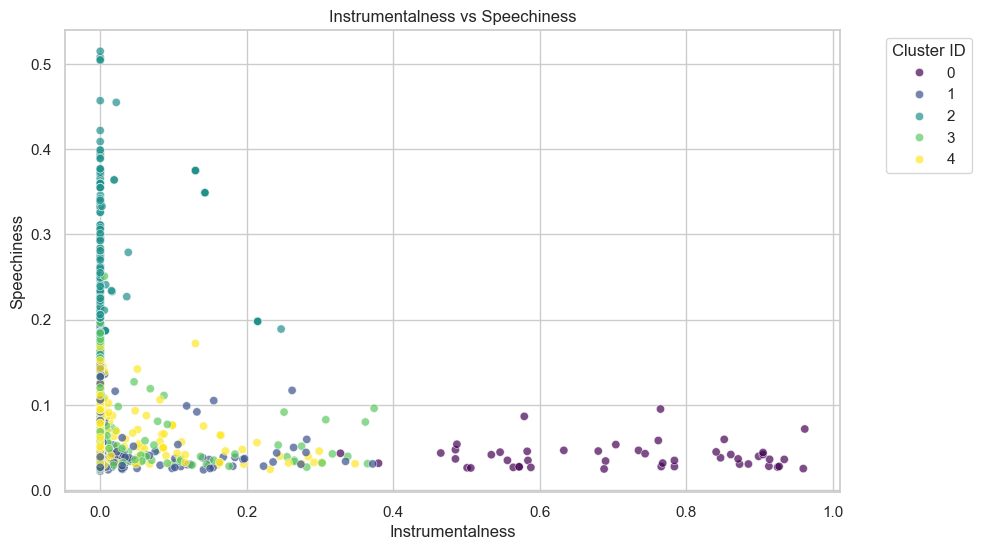

In [85]:
plt.figure(figsize = (10, 6))

sns.scatterplot(
    data=df_clean_with_genres,
    x="instrumentalness",
    y="speechiness",
    hue="cluster_id",
    palette="viridis",
    alpha=0.7,
)

plt.title("Instrumentalness vs Speechiness")
plt.xlabel("Instrumentalness")
plt.ylabel("Speechiness")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Here we plot Instrumentalness vs Speechiness.

This graph shows an interesting l shaped pattern which makes sense given our clusters.
The majority of cluster 2 is seen climbing the y-axis which makes sense since it has the most hip-hop songs which usually do place a higher importance on density of lyrics over instrumentals. Another interesting trend in this graph is that the outlier cluster 0 is mostly occupying the bottom right half of the graph which might suggest that these outliers are instrumentals and make sense why they are so distinct from the other songs in the set.

Finally, the average song in this set seems to have a mix between the two features which makes sense given the average song in genres such as pop will usually strike a balance between the two.

## F. Calculating DBSCAN

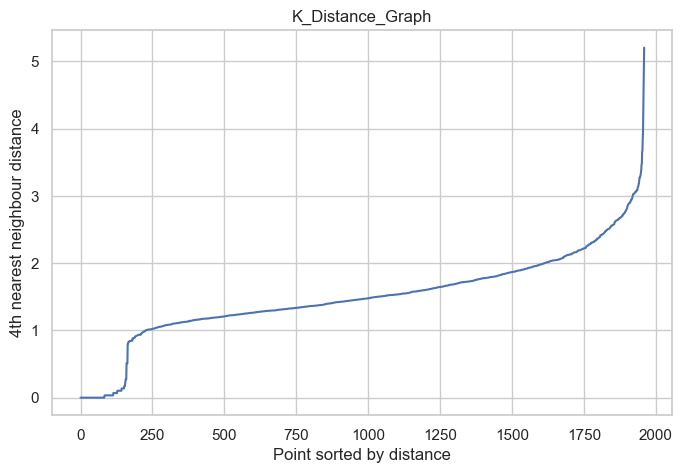

In [82]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

distances = np.sort(distances[:, 3], axis=0)
plt.figure(figsize = (8, 5))
plt.plot(distances)
plt.title("K_Distance_Graph")
plt.xlabel("Point sorted by distance")
plt.ylabel("4th nearest neighbour distance")
plt.grid(True)
plt.show()


    Before calculating the DBSCAN we first have to calculate the epsilon value we are gonna use for the algorithm for this we can use a similar approach that we used to calculate the optimal amount clusters for K mean, this approach is known as K-Distance graph.

    This method works by calculating the distance to the k-th nearest neighbor for each point. We then plot these points in ascending order. Once this is done we look for the elbow on the graph where we start to receive diminishing returns and this point is our optimal epsilon for DBSCAN.

    For our graph the elbow is roughly between 2 and 2.8 so we decided a epsilon value of 2.5 would fit our data.

In [96]:
dbscan = DBSCAN(eps=2.5, min_samples=5)

db_labels = dbscan.fit_predict(df_scaled)

df_clean_with_genres['dbscan_cluster'] = db_labels

dbscan_comparison = pd.crosstab(df_clean_with_genres['dbscan_cluster'], df_clean_with_genres['track_genre'])

print(dbscan_comparison)
n_noise = list(db_labels).count(-1)
print("\n Number of noise points", n_noise)

track_genre     hip-hop  indie-pop  pop  r-n-b  synth-pop
dbscan_cluster                                           
-1                    7         19    9     13         31
 0                  284        467  477    280        350
 1                    1          8    2      0          7
 2                    0          0    0      0          5

 Number of noise points 79


For the DBSCAN the most obvious takeaway we can make is that the majority of data falls into cluster 0 besides a small few points.

What this tells us is that these features that we are using to determine the genre are greatly interconnected and share a similar density which makes it hard for the algorithm to separate them.

The algorithm was useful at identifying outliers which can be seen in the -1 cluster, and it successfully identified 79 points of noise.

Comparing DBSCAN to K-means
We found K-means was much more successful at clustering our data set into meaningful clusters as based on our analysis it actually found some patterns based on certain features. It found patterns such as hip-hop having high speechiness.

DBSCAN showed us that the difference between the features are too subtle and a lack of empty space which lead to all the points being part of 1 cluster.

Given the two methods K-means was found to be a more effective clustering technique for our project as it clusters better than the alternative based on the genre.